# Measurement of W + charm production using CMS Open Data:

This notebook involves the study of **W+charm** using CMS Open Data with W+Jets in final state. 

## Key Idea: 

This study is of the associated production of a W boson and a charm(c) quark at the LHC. This provides direct access to strange quark content of the proton at the W-boson mass energy scale. This sensitivity is due to dominance of $\bar{q}g \rightarrow W^{+} + \bar{c}$ and $qg \rightarrow W^{-} + c$ contibutions at leading order.

## Sample Used:

- **Simulated Dataset:** [Simulated dataset WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8 in NANOAODSIM format for 2016 collision data](https://opendata.cern.ch/record/69747). 80958227 events. 68 files. 73.9 GiB in total. (Here we take only partially available file - 2006990 events).

- **Collision Dataset:** TBA

## 1. Setup:

We use `coffea` for event processing, `awkward-array` and `dask` for jagged array handling, and `mplhep` to produce publication-ready CMS plots. All of them are available in the **Scikit-HEP** toolkit.

We also import `hist_functions` which contains helper plotter functions `make_hist`, `make_diff_hist`, `make_overlay_hist` and `os_ss_hist`.

In [1]:
import hist as h
import dask_awkward as dak
import numpy as np
import hist.dask as dhist
import hist_functions
from hist_functions import make_hist, make_diff_hist, make_overlay_hist, os_ss_hist
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
vector.register_awkward()

NanoAODSchema.warn_missing_crossrefs = False

## 2. Loading the data:
We load the WJetsToLNu sample of simulated $W\rightarrow \ell + \nu$. `dask` is used to lazily read the file to save resources and only read from disk whenever necessary.

In [2]:
# fname = "../../datasets/WJets_ToLNu_NANOAODSIM.root"
fname = "../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root"
print(f"Loading file: {fname}")
events = NanoEventsFactory.from_root(
    {fname: "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

Loading file: ../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root


dask.awkward<from-uproot, npartitions=1>

## 3. Event Selection Strategy:

### Analysis Strategy:

The Event selection strategy is as follows:
- **W-Boson selection:** Indetification of W-boson is done via its leptonic decay channel ($W \rightarrow \mu + \nu$) where we select high-$p_{T}$, isolated "tight" muons and missing transverse energy ($p_{T}^{miss}$).
- **Charm selection:** Identification of charm is done by looking for non-isolated "soft" muons from semi-leptonic decays of C-Hadron ($c \rightarrow s\mu\nu$).
- **OS-SS Subtraction:** The muon associated with the W-boson and the muon associated with the c-jet should have **opposite sign (OS)**. Here background processes like gluon splitting processes, Drell-Yan or $t\bar{t}$ are charge symmetric. By subtracting **same sign (SS)** events from OS events, we statistically reduce the background to obtain the signal.  

### Some Important Notes:

- In the $W+charm$ process at leading-order (LO), the electric charges of the $W$ boson and the $charm$ quark have opposite sign(OS).

- **Background:** Gluon splitting $q\bar{q} \rightarrow W + g \rightarrow W + c\bar{c}$ process produces both $c$ and $\bar{c}$; so the OS and SS events are both equally likely.  

- Detectors often reconstruct/tag only one c-jet candidate out of the two in the gluon splitting process.

- With only one picked c-jet, gluon splitting events becomes OS/SS-symmetric. That OS and SS yields from this background is equally likely.

- Why only one c-jet is tagged? The reason is limited acceptance, reconstruction efficiency and c-tagging efficiency meaning often times the detector can only reconstruct one of the either c-jet candidate from $g \rightarrow c\bar{c}$. The untagged c-jet candidate might be too soft or too forward to pass trigger or fail tagging.

- In $W + g \rightarrow g \rightarrow c \bar{c}$ background, if we keep a fixed $W$ charge. Let $S$ be true signal, $B$ a symmetric background: $N_{OS} = S + \dfrac{1}{2}B$ and $N_{SS} = 0 + \dfrac{1}{2}B$. Then subtract $N_{OS} - N_{SS}$, this cancels background and only signal remains. Here $N_{OS}$ and $N_{SS}$ are yields of opposite-sign and same-sign events.

## 4. Pre-selection and Initial Sanity Checks:

Here, we will select make object collections of _Muons_, _MET_ and _Jets_ that we will use later on in our analysis and also make some initial sanity checks and plots.

In [3]:
print("Defining Physics Objects...")

cutflow = {}

# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet
GenJets = events.GenJet
GenPart = events.GenPart

print("Defining physics objects ... Successful!")
print("--------------------------------------------")
# Count the number of events in the dataset:
n_events = dak.num(events, axis=0)
print("Total number of events in the dataset:", n_events.compute())

# --- CUTFLOW 1 --- #
cutflow["1. Total Events"] = n_events

# Count the number of muons in the dataset:
nMuons = dak.num(Muon, axis=1)
total_Muons = dak.sum(nMuons)
print("Total number of muons in the dataset:", total_Muons.compute())

# Count the number of jets in the dataset:
nJets = dak.num(Jet, axis=1)
total_Jets = dak.sum(nJets)
print("Total number of jets in the dataset:", total_Jets.compute())

# Count the number of GenJets and GenParticles in the dataset:
nGenJets = dak.num(GenJets, axis=1)
total_GenJets = dak.sum(nGenJets)
print("Total number of generator level jets in the dataset:", total_GenJets.compute())

nGenPart = dak.num(GenPart, axis=1)
total_GenPart = dak.sum(nGenPart)
print("Total number of generator level particles in the dataset:", total_GenPart.compute())

Defining Physics Objects...
Defining physics objects ... Successful!
--------------------------------------------
Total number of events in the dataset: 250000
Total number of muons in the dataset: 94049
Total number of jets in the dataset: 940357
Total number of generator level jets in the dataset: 685752
Total number of generator level particles in the dataset: 5938949


## 5. Matching and looking into GenParticles and GenJets:

Here we will take a look into GenParticles and GenJets for truth level information. Let's look at the `hadronFlavour` information of GenJets to get the truth level information of how many charm jets were produced in the generator level:

- For **charm (c)** `hadronFlavour == 4`
- For **bottom (b)** `hadronFlavour == 5`
- For **Light Jets (udsg)** `hadronFlavour == 0`

> **TO DO:** Truth Check - Gen Level Charm Hadrons vs Reco Level Charm Hadrons - Compare the numbers.

## 5(a). Testing out Generator-level and Reco-level matching of Jets:

This is where the GenJets and the RecoJets are matched based on their $\Delta R$. If a RecoJet is within the $\Delta R < 0.4$ of a GenJet, we consider the Jet to be a *GoodJet* and keep it.

In [4]:
# Gen-Matching between GenJets and RecoJets:
GenJets_cut = (
    (GenJets.pt > 20) &
    (abs(GenJets.eta) < 2.4)
)
RecoJets_cut = (
    (Jet.pt > 20) &
    (abs(Jet.eta) < 2.4)
)
# Select the GenJets and RecoJets that pass the cuts:
TestGenJets = GenJets[GenJets_cut]
TestRecoJets = Jet[RecoJets_cut]

nTestGenJets = dak.sum(dak.num(TestGenJets, axis=1))
nTestRecoJets = dak.sum(dak.num(TestRecoJets, axis=1))
print("Number of GenJets that pass the cuts:", nTestGenJets.compute())
print("Number of RecoJets that pass the cuts:", nTestRecoJets.compute())

# DeltaR matching of GenJets and RecoJets:
dR = TestRecoJets.metric_table(TestGenJets)
# print("DeltaR of GenJets and RecoJets:",dR.compute())

# Minimum DeltaR for each RecoJet to any GenJet
min_dR = dak.min(dR, axis=2)
# print("Minimum DeltaR for each RecoJet to any GenJet:", min_dR.compute())

# The index of the GenJet that is closest to each RecoJet
matched_jet_index = dak.argmin(dR, axis=2)
# print("Index of the closest GenJet for each RecoJet:", matched_jet_index.compute())
min_dR = dak.fill_none(min_dR, 99999)
dR_cut = (min_dR < 0.4)

Good_TestGenJets = TestGenJets[matched_jet_index[dR_cut]]
Good_TestRecoJets = TestRecoJets[dR_cut]

Number of GenJets that pass the cuts: 277622
Number of RecoJets that pass the cuts: 367792


In [5]:
nTestRecoJets = dak.sum(dak.num(Good_TestRecoJets, axis=1))
print("Number of RecoJets that are matched to GenJets:", nTestRecoJets.compute())

Number of RecoJets that are matched to GenJets: 259725


## 5(b). Matching GenJets and RecoJets after hadron flavour selection:

Now we match the GenJets and RecoJets by also considering their `HadronFlavour` == 4. This ensures that the jets contain a C-Hadron exclusively.

In [6]:
GenCharmHF_Cut = (
    GenJets.hadronFlavour == 4
)
RecoCharmHF_Cut = (
    Jet.hadronFlavour == 4
)
GenCharmJets = GenJets[GenCharmHF_Cut]
RecoCharmJets = Jet[RecoCharmHF_Cut]

nGenCharmJets = dak.sum(dak.num(GenCharmJets, axis=1))
nRecoCharmJets = dak.sum(dak.num(RecoCharmJets, axis=1))
print("Number of GenCharmJets that pass the cuts:", nGenCharmJets.compute())
print("Number of RecoCharmJets that pass the cuts:", nRecoCharmJets.compute())

# Delta R matching of these GenCharmJets and RecoCharmJets:
dR = RecoCharmJets.metric_table(GenCharmJets)
min_dR = dak.min(dR, axis=2)
matched_jet_index = dak.argmin(dR, axis=2) # Gets the index of the closest GenCharmJet for each RecoCharmJet

min_dR = dak.fill_none(min_dR, 99999)
dR_cut = (min_dR < 0.4)

Good_GenCharmJets = GenCharmJets[matched_jet_index[dR_cut]]
Good_RecoCharmJets = RecoCharmJets[dR_cut]

Number of GenCharmJets that pass the cuts: 46265
Number of RecoCharmJets that pass the cuts: 40492


In [7]:
nGood_RecoCharmJets = dak.sum(dak.num(Good_RecoCharmJets, axis=1))
# --- CUTFLOW 2 --- #
cutflow["2. GoodRecoCharmJets"] = nGood_RecoCharmJets
print("Number of RecoCharmJets that are matched to GenCharmJets:", nGood_RecoCharmJets.compute())

Number of RecoCharmJets that are matched to GenCharmJets: 34088


## 5(c). Matching GenMuons and RecoMuons:

We also verify generator-level Muons and Reco-level Muons match each other and get a good sanity check of our truth-level information of the leptons.

In [8]:
# We use the pdgID information of GenParticles to identify generator level muons:
genMuon_pdgId = (abs(GenPart.pdgId)) == 13

GenMuons = GenPart[genMuon_pdgId]
nGenMuons = dak.sum(dak.num(GenMuons, axis=1))
print("Number of generator level muons in the dataset:", nGenMuons.compute())
nRecoMuons = dak.sum(dak.num(Muon, axis=1))
print("Number of reconstructed muons in the dataset:", nRecoMuons.compute())

Number of generator level muons in the dataset: 176124
Number of reconstructed muons in the dataset: 94049


In [9]:
# Gen-Matching between GenMuons and RecoMuons:
dR = Muon.metric_table(GenMuons)
min_dR = dak.min(dR, axis=2)
matched_muon_index = dak.argmin(dR, axis=2) 

min_dR = dak.fill_none(min_dR, 99999)
dR_cut = (min_dR < 0.4)

Good_RecoMuons = Muon[dR_cut]

In [10]:
# Number of RecoMuons that are matched to GenMuons:
nGood_RecoMuons = dak.sum(dak.num(Good_RecoMuons, axis=1))
# --- CUTFLOW 3 --- #
cutflow["3. GoodRecoMuons"] = nGood_RecoMuons
print("Number of RecoMuons that are matched to GenMuons:", nGood_RecoMuons.compute())

Number of RecoMuons that are matched to GenMuons: 71986


## 6. W Boson Selection:

The following cuts are applied to obtain a high-$p_{T}$
and isolated "tight muon" with the trigger `HLT_IsoMu24`:

- Muon $p_{T}$ > 25 GeV. (high-$p_{T}$)
- Muon $\eta$ < 2.4.
- Muon `pfRelIso04_all` < 0.15. (isolated)
- Muon `tightID` == True.

We additionally also put a cut on the Transverse Mass ( $M_{T}$ > 50 GeV) of Muon+MET system to ensure the selected candidate is associated with a W-Boson.

In [11]:
print("Defining W Selection ...")
######################################
## W-Boson -> Mu Nu Channel Selection:
######################################

# W-Boson selection cuts:
W_MuMask = (
    (Good_RecoMuons.pt > 30) &
    (abs(Good_RecoMuons.eta) < 2.4) &
    (Good_RecoMuons.tightId == 1) &
    (Good_RecoMuons.pfRelIso04_all < 0.15)
    )

# Transverse mass calculation and cut:
Mt = np.sqrt(2 * Good_RecoMuons.pt * MET.pt * (1 - np.cos(Good_RecoMuons.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Good_RecoMuons[W_MuMask]

# Select events with exactly ONE W muon:
nMu = dak.num(W_Muons, axis=1)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

nMu = dak.num(W_Muons, axis=1)
nMu = dak.sum(nMu)
# --- CUTFLOW 4 --- #
cutflow["4. W-Muons after cuts"] = nMu
print("Total number of W muons:", nMu.compute())

Defining W Selection ...
Total number of W muons: 26202


## 7. Charm Selection:

The following cuts are applied to obtain a non-isolated "soft" muon:

- Muon $p_{T}$ < 25 GeV.
- Muon $\eta$ < 2.4. 
- Muon `pfRelIso04_all` > 0.2. (non-isolated)
- Muon `tightID` == True.
- Muon `sip3d` > 2.

Then we match these soft muons with the nearest jets and categorise them as c-jets (jets originating from c-Hadrons). The jets should also have: $p_{T}$ > 30 GeV and $\eta$ < 2.

In [12]:
# print("Defining charm Selection ...")
# ###############################################
# ## C-jet -> Mu X Channel Selection (soft muon):
# ###############################################

# cMuPassCuts = (
#     (Good_RecoMuons.pt < 25) &
#     (abs(Good_RecoMuons.eta) < 2.4) &
#     (Good_RecoMuons.pfRelIso04_all > 0.2) &
#     (Good_RecoMuons.jetIdx >= 0) 
#     # (Good_RecoMuons.tightId == 1)
# )
# # Impact parameter significance cut (3D):
# sip2d = (abs(Good_RecoMuons.dxy) / Good_RecoMuons.dxyErr) 
# sip3d = Good_RecoMuons.sip3d
# ip2dSigMask = (sip2d > 2)
# ip3dSigMask = ((sip3d) > 2)

# soft_muon = Good_RecoMuons[cMuPassCuts & ip3dSigMask]

# # Print the number of soft muons passing the selection:
# nSoftMuons = dak.num(soft_muon, axis=1)
# total_SoftMuons = dak.sum(nSoftMuons)
# print("Total number of soft muons:", total_SoftMuons.compute())

# ###############################################
# ## Jet matching via jetIdx (soft muon <-> jets)
# ## - uses Muon.jetIdx to pick the matched jet
# ## - applies jet kinematic cuts on matched jets
# ###############################################

# # Matched jets for each soft muon (evt, nMu)
# matched_jets = Good_RecoCharmJets[soft_muon.jetIdx]

# # Apply jet kinematic cuts to matched jets
# matched_jet_mask = (
#     (matched_jets.pt > 30) &
#     (abs(matched_jets.eta) < 2.4)
# )

# # Keep only soft muons and matched jets passing jet cuts
# soft_muon_in_goodjet = soft_muon[matched_jet_mask]
# c_Jets = matched_jets[matched_jet_mask]

# # Summary of matched jets passing cuts
# nMatchedJets = dak.num(c_Jets, axis=1)
# total_MatchedJets = dak.sum(nMatchedJets)
# print("Total number of matched jets passing cuts:", total_MatchedJets.compute())

# # Select events with atleast one c-jet:
# nC_Jets = dak.num(c_Jets, axis=1)
# evt_has_cJet = (nC_Jets >= 1)
# c_Jets = c_Jets[evt_has_cJet]

# # Total number of cJets in the dataset:
# nC_Jets = dak.num(c_Jets, axis=1)
# total_cJets = dak.sum(nC_Jets)

# # --- CUTFLOW 3 --- #
# cutflow["3. c-Jets after cuts"] = total_cJets
# print("Total number of c-jets in the dataset:", total_cJets.compute())

In [13]:
# print("Alternative: Delta-R matching charm Selection ...")
# ###############################################
# ## C-jet -> Mu X Channel Selection (soft muon):
# ## Using Delta-R based muon-jet matching
# ###############################################

# # Same soft muon selection as before
# cMuPassCuts_dR = (
#     (Muon.pt < 25) &
#     (abs(Muon.eta) < 2.4) &
#     (Muon.pfRelIso04_all > 0.2)
# )

# # Impact parameter significance cuts
# sip3d_dR = Muon.sip3d
# ip3dSigMask_dR = (sip3d_dR > 2)

# soft_muon_dR = Muon[cMuPassCuts_dR & ip3dSigMask_dR]

# nSoftMuons_dR = dak.num(soft_muon_dR, axis=1)
# total_SoftMuons_dR = dak.sum(nSoftMuons_dR)
# print(f"Total soft muons (before matching): {total_SoftMuons_dR.compute()}")

# # Apply basic jet kinematic cuts first
# jet_cuts = (
#     (Jet.pt > 30) &
#     (abs(Jet.eta) < 2.4)
# )
# good_jets = Jet[jet_cuts]

# ###############################################
# ## Delta-R based muon-jet matching
# ## - computes dR between each muon-jet pair
# ## - matches each muon to its nearest jet
# ## - applies dR < 0.4 cone matching criterion
# ###############################################

# # Compute deltaR between all soft muon - good jet combinations
# # Results in shape (n_events, n_muons, n_jets)
# dR = soft_muon_dR.metric_table(good_jets)
# print(f"The deltaR of soft muons and good jets are:", dR.compute())
# # For each muon, find index of nearest jet
# nearest_jet_idx = dak.argmin(dR, axis=2)

# # Get the minimum deltaR for each muon
# min_dR = dak.min(dR, axis=2)

# # Apply matching criterion: dR < 0.4
# is_matched = (min_dR < 0.4)

# # Keep only matched muons
# soft_muon_matched = soft_muon_dR[is_matched]

# # To extract matched jets, we need to index good_jets with nearest_jet_idx
# # For the matched muons only
# # We'll build the matched jet collection per-event using the indices

# # Extract matched jets using awkward array indexing
# # Create a builder or use direct indexing per event
# def get_matched_jets(jets, indices, mask):
#     """Extract jets at given indices where mask is True"""
#     matched_jets = []
#     for evt_jets, evt_indices, evt_mask in zip(jets, indices, mask):
#         if len(evt_mask) > 0:
#             matched_evt_jets = evt_jets[evt_indices[evt_mask]]
#             matched_jets.append(matched_evt_jets)
#         else:
#             matched_jets.append(evt_jets[:0])  # empty array with same type
#     return matched_jets

# # Note: Direct implementation for dask-awkward
# # matched_jets_dR = good_jets[nearest_jet_idx][is_matched] would work if indexing supports it
# # A simpler approach: use where is_matched, select the jet at nearest_jet_idx

# # For now, we'll just track that matching was done and report statistics
# total_matched = dak.sum(dak.num(soft_muon_matched, axis=1))
# print(f"Total muon-jet pairs matched (dR < 0.4): {total_matched.compute()}")

# # Select events with at least one matched pair
# nMatched_dR = dak.num(soft_muon_matched, axis=1)
# evt_has_cJet_dR = (nMatched_dR >= 1)

# total_evt_dR = dak.sum(evt_has_cJet_dR)
# print(f"Events with >=1 c-jet (dR method): {total_evt_dR.compute()}")

# # For downstream analysis, c_Jets_dR would be constructed by properly indexing good_jets
# # c_Jets_dR = good_jets[nearest_jet_idx where is_matched]

In [34]:
print("Defining charm Selection ...")
###############################################
## C-jet -> Mu X Channel Selection (soft muon):
###############################################

cMuPassCuts = (
    (Good_RecoMuons.pt < 25) &
    (abs(Good_RecoMuons.eta) < 2.4) &
    (Good_RecoMuons.pfRelIso04_all > 0.2)  
    # (Good_RecoMuons.tightId == 1)
)
# Impact parameter significance cut (3D):
dxy_err_ok = abs(Good_RecoMuons.dxyErr) > 0 # just a safe check to avoid division by zero
sip2d = abs(Good_RecoMuons.dxy) / Good_RecoMuons.dxyErr 
sip3d = Good_RecoMuons.sip3d
ip2dSigMask = (sip2d > 2)
ip3dSigMask = (abs(sip3d) > 2)

soft_muon = Good_RecoMuons[cMuPassCuts & ip3dSigMask]

# Print the number of soft muons passing the selection:
nSoftMuons = dak.num(soft_muon, axis=1)
total_SoftMuons = dak.sum(nSoftMuons)
print("Total number of soft muons:", total_SoftMuons.compute())

###############################################
## dR matching (soft muon <-> jets)
## - builds all muon-jet pairs per event
## - picks nearest jet per muon
## - requires min dR < dr_cut
###############################################

# Jets eligible for matching (apply your jet kinematic cuts here)
jets = Good_RecoCharmJets[
    (Good_RecoCharmJets.pt > 30) &
    (abs(Good_RecoCharmJets.eta) < 2.4)
]

# Summary of jet availability for matching:
njets = dak.num(jets, axis=1)
total_Jets = dak.sum(njets)
# --- CUTFLOW 5 --- #
cutflow["5. GoodJets after cuts"] = total_Jets
print("Total number of jets eligible for matching:", total_Jets.compute())

# Pairwise muon-jet combinations within each event: (evt, nMu, nJet)
dr = soft_muon.metric_table(jets) 
min_dr = dak.min(dr, axis=2) # Gets the nearest jet distance for each muon
best_jet_idx = dak.argmin(dr, axis=2) # Gets the index of the nearest jet for each muon 
min_dr = dak.fill_none(min_dr, 99999) 

# Require a valid match within dr_cut
has_match = (min_dr < 0.4)

# Keep only matched soft muons and their matched jets
soft_muon_in_goodjet = soft_muon[has_match]
c_Jets = jets[best_jet_idx]
c_Jets = c_Jets[has_match]

# Select events with atleast one c-jet:
nC_Jets = dak.num(c_Jets, axis=1)
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

# Total number of cJets in the dataset:
nC_Jets = dak.num(c_Jets, axis=1)
total_cJets = dak.sum(nC_Jets)
## --- CUTFLOW 6 --- ##
cutflow["6. c-Jets after cuts"] = total_cJets
print("Total number of c-jets in the dataset:", total_cJets.compute())

red_rat = (abs(total_Jets - nGood_RecoCharmJets)/nGood_RecoCharmJets).compute()
print(f"Reduction factor from good jets to matched jets: {red_rat:.4f}")

red_rat_cjets = (abs(total_cJets - total_Jets)/total_Jets).compute()
print(f"Reduction factor from matched jets to matched c-jets: {red_rat_cjets:.4f}")

Defining charm Selection ...
Total number of soft muons: 2662
Total number of jets eligible for matching: 13058
Total number of c-jets in the dataset: 351
Reduction factor from good jets to matched jets: 0.6169
Reduction factor from matched jets to matched c-jets: 0.9731


## 8. Signal Extraction:

We want exactly one W boson candidate and at least one c-jet candidate. We then separate them into **Opposite Sign (OS)** (Signal + Background) and **Same Sign (SS)** (Background Only).

In [15]:
print("Defining Signal Region...")

# W+c Event Mask: events with exactly one W muon and at least one c-jet:
Wc_evt_mask = evt_has_1WMu & evt_has_cJet
nWC_Events = dak.sum(Wc_evt_mask)
print("The number of events containing W+c candidates:", nWC_Events.compute())

# --- CUTFLOW 7 --- #
cutflow["7. W+c Events"] = nWC_Events

# Align masks to already-filtered collections
evt_has_cJet_in_W = evt_has_cJet[evt_has_1WMu]
evt_has_1WMu_in_c = evt_has_1WMu[evt_has_cJet]

# Apply aligned masks
Final_W = W_Muons[evt_has_cJet_in_W]
soft_muon_final = soft_muon_in_goodjet[Wc_evt_mask]
c_jets_final = c_Jets[evt_has_1WMu_in_c]

# OS - SS categorization using broadcast:
w_charge = Final_W.charge[:, 0]
soft_charge = soft_muon_final.charge

# Broadcast W charge to match number of soft muons
w_charge_broadcast = dak.broadcast_arrays(w_charge, soft_charge)[0]

is_OS = w_charge_broadcast != soft_charge
is_SS = w_charge_broadcast == soft_charge

# Now OS/SS masks are aligned with both c_jets_final and soft_muon_final
cjet_pt_OS = dak.flatten(c_jets_final[is_OS].pt)
cjet_pt_SS = dak.flatten(c_jets_final[is_SS].pt)

# Count OS/SS lepton pairs
nOS_pairs = int(dak.sum(is_OS).compute())
nSS_pairs = int(dak.sum(is_SS).compute())
print(f"OS lepton pairs: {nOS_pairs}")
print(f"SS lepton pairs: {nSS_pairs}")

Defining Signal Region...
The number of events containing W+c candidates: 60
OS lepton pairs: 58
SS lepton pairs: 3


## 9. Plots and Compute:

Let's plot all the control plots and also compute them as we plot them (intrinsically built into the `hist_functions`). The plots are to see if we need to put any additional cuts or tune our cuts to increase yields. 

Generating Test Histograms...


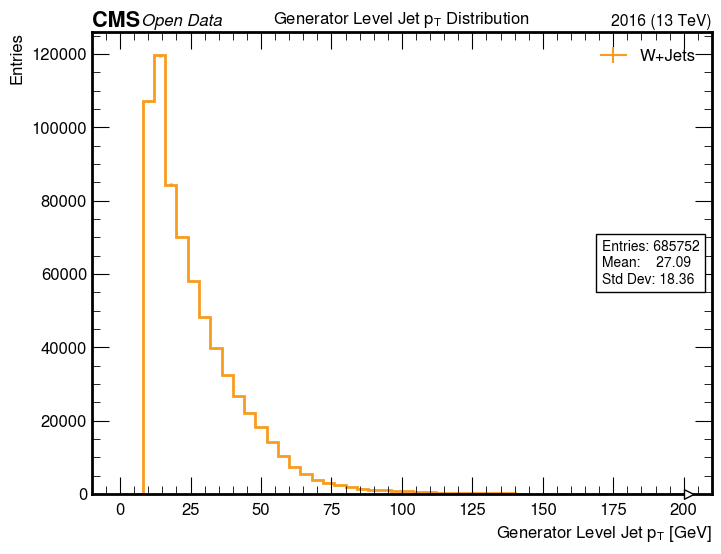

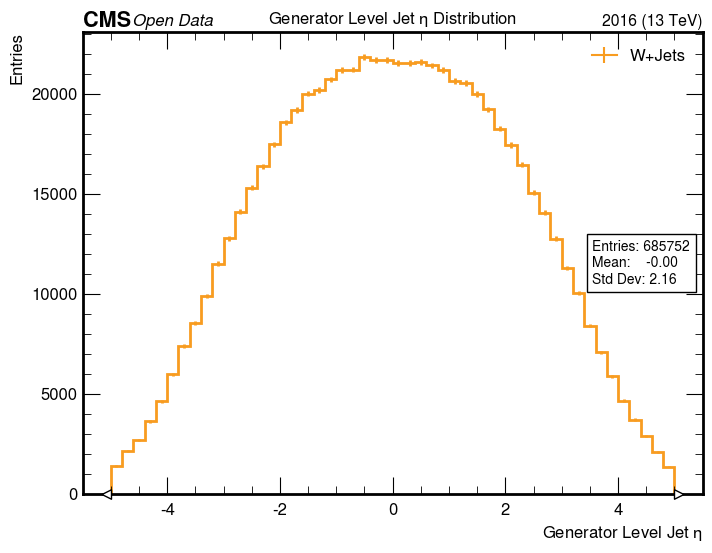

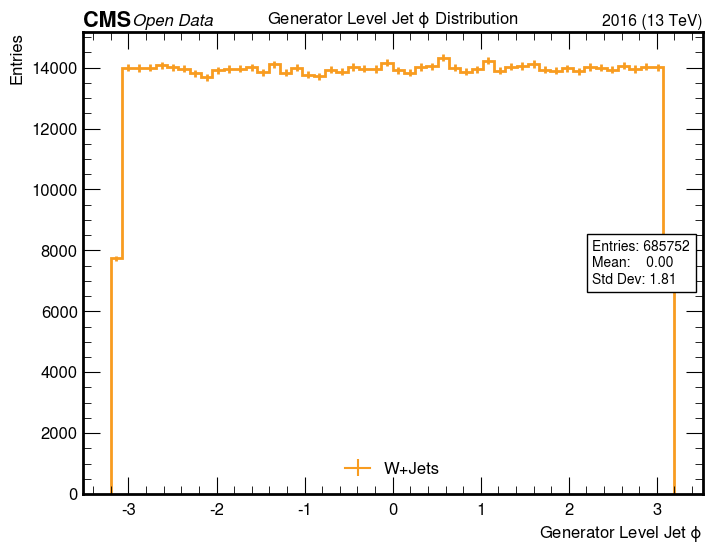

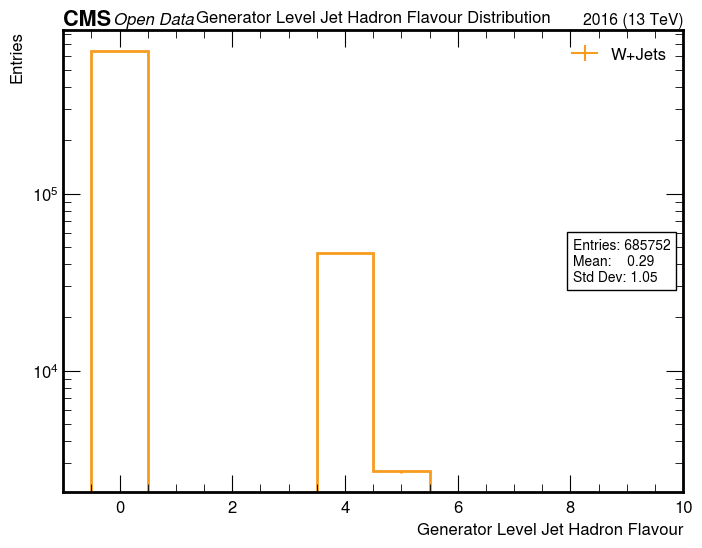

Total number of generator level charm jets in the dataset: 46265


In [16]:
print("Generating Test Histograms...")

GenJets_pt = dak.flatten(GenJets.pt)
make_hist(
    GenJets_pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="Generator Level Jet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+Jets",
    title="Generator Level Jet $p_{T}$ Distribution",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",    
)
GenJets_eta = dak.flatten(GenJets.eta)
make_hist(
    GenJets_eta,
    nBins=50,
    lo=-5,
    hi=5,
    xlabel="Generator Level Jet $\\eta$",
    ylabel="Entries",
    label="W+Jets",
    title="Generator Level Jet $\\eta$ Distribution",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",    
)

GenJets_phi = dak.flatten(GenJets.phi)
make_hist(
    GenJets_phi,
    nBins=50,
    lo=-3.2,
    hi=3.2,
    xlabel="Generator Level Jet $\\phi$",
    ylabel="Entries",
    label="W+Jets",
    title="Generator Level Jet $\\phi$ Distribution",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",    
)

GenJets_HadronFlavour = dak.flatten(GenJets.hadronFlavour)
make_hist(
    GenJets_HadronFlavour,
    nBins=10,
    lo=-0.5,
    hi=9.5,
    xlabel="Generator Level Jet Hadron Flavour",
    ylabel="Entries",
    label="W+Jets",
    title="Generator Level Jet Hadron Flavour Distribution",
    fname=None,
    logy=True,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",    
)

# Number of Generator level charm jets:
nGenCharmJets = dak.num(GenCharmJets, axis=1)
total_GenCharmJets = dak.sum(nGenCharmJets)
print("Total number of generator level charm jets in the dataset:", total_GenCharmJets.compute())

Generating histograms...


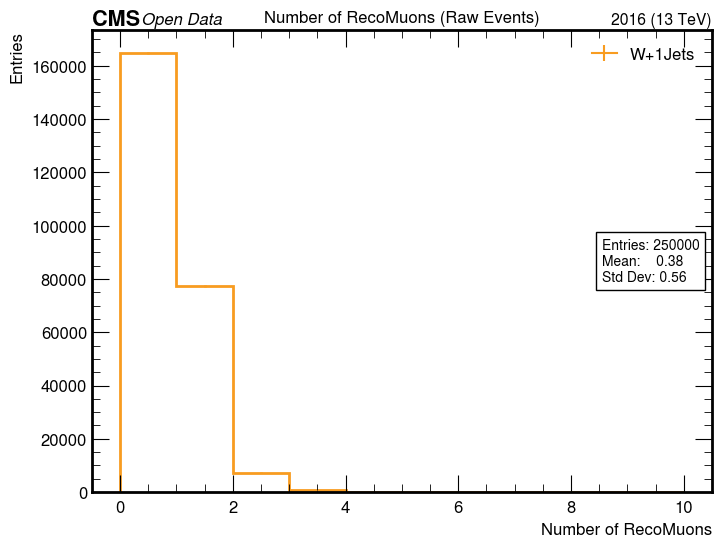

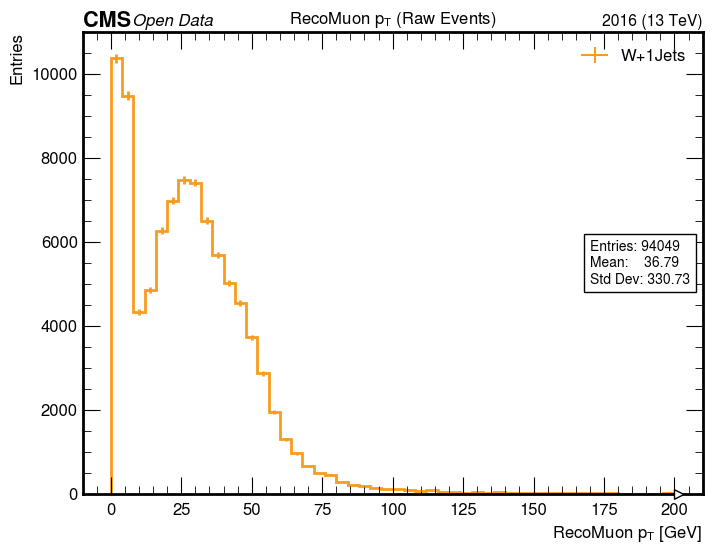

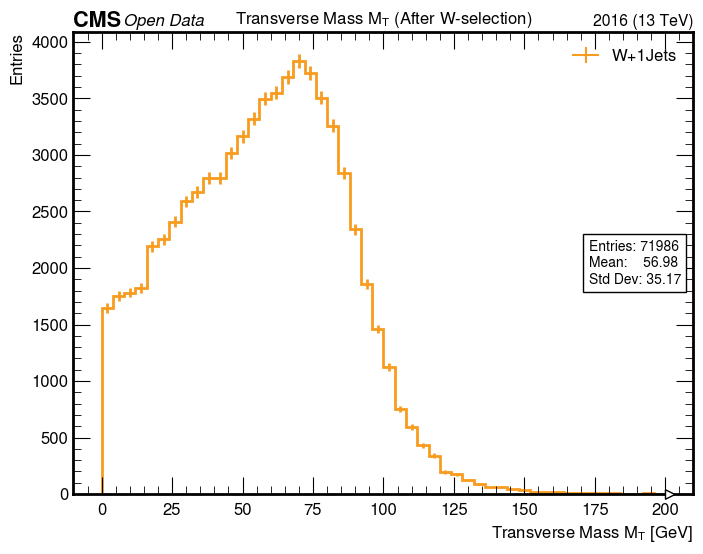

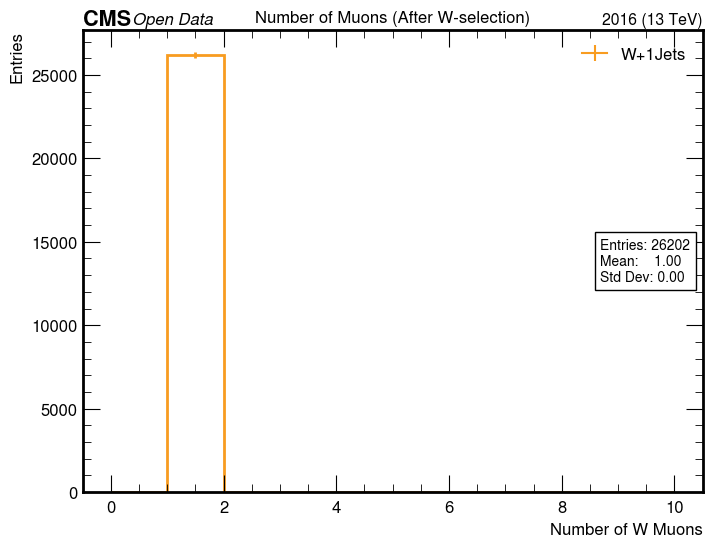

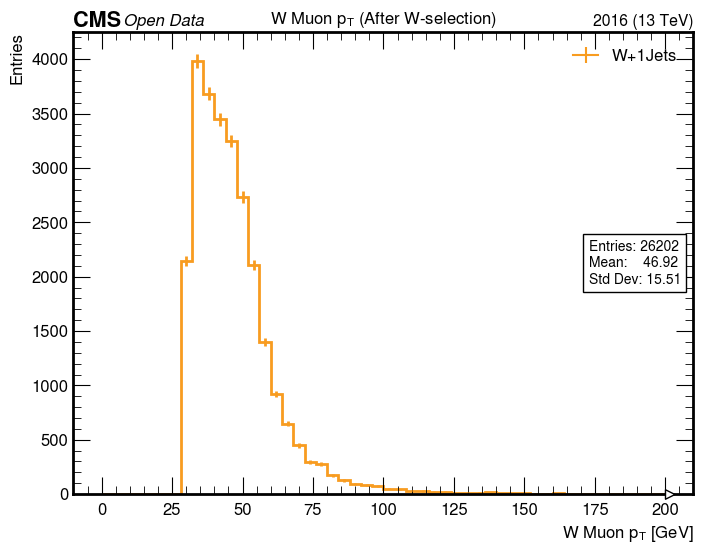

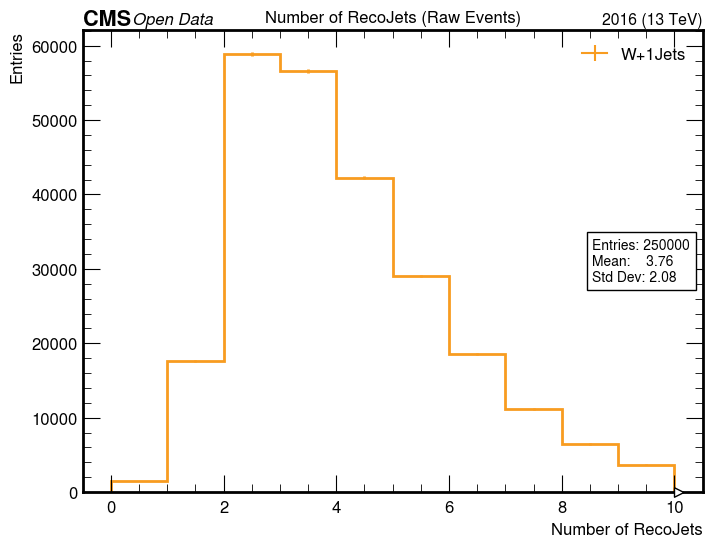

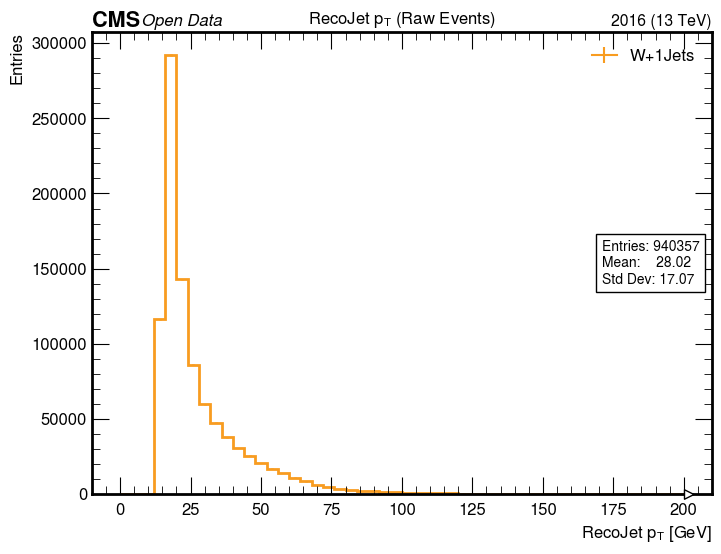

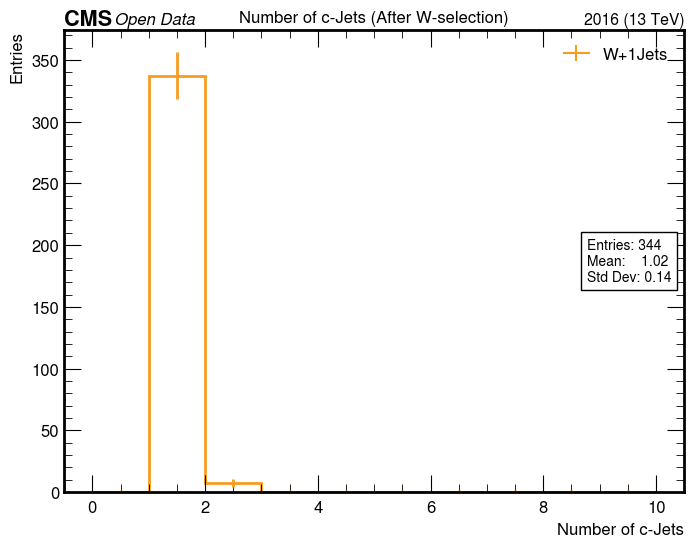

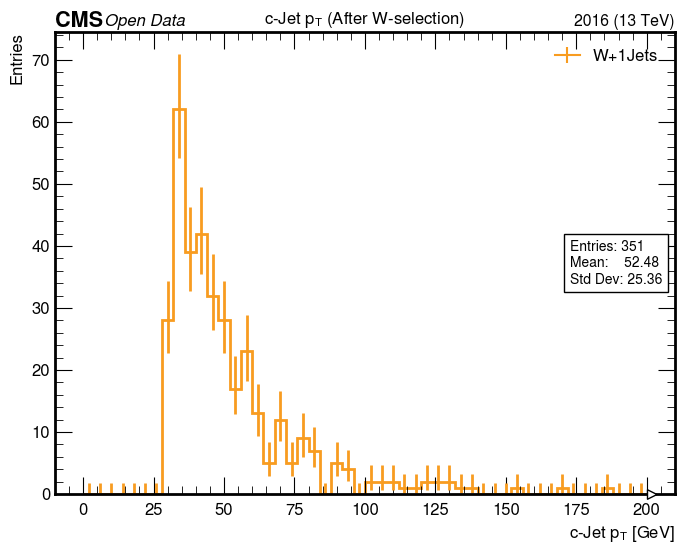

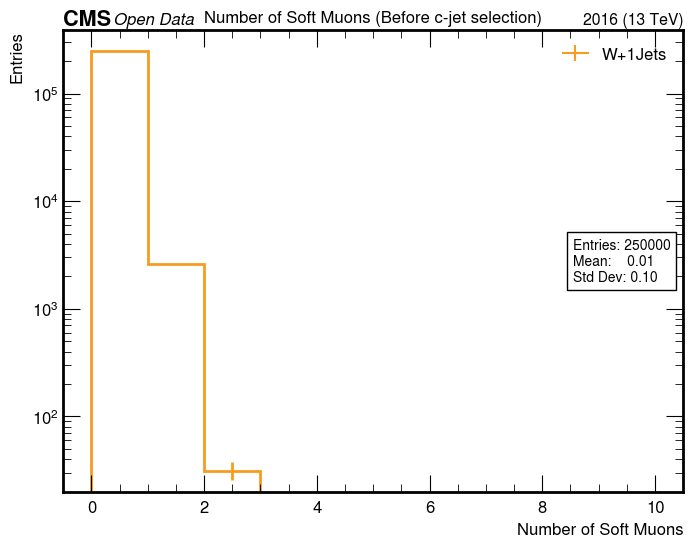

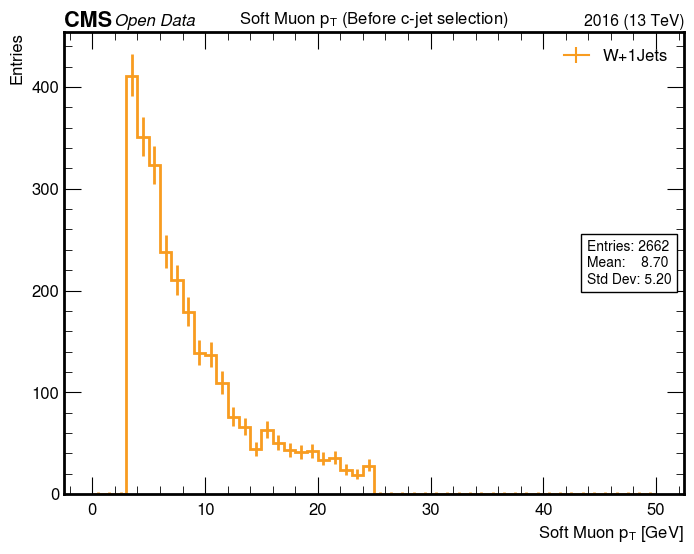

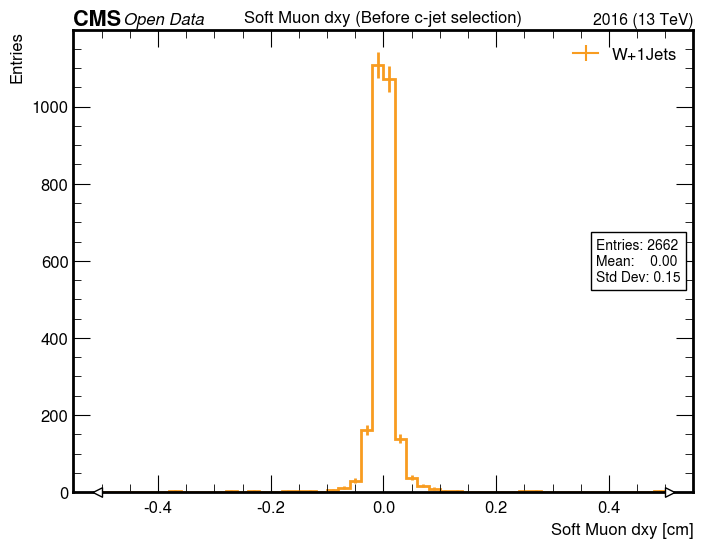

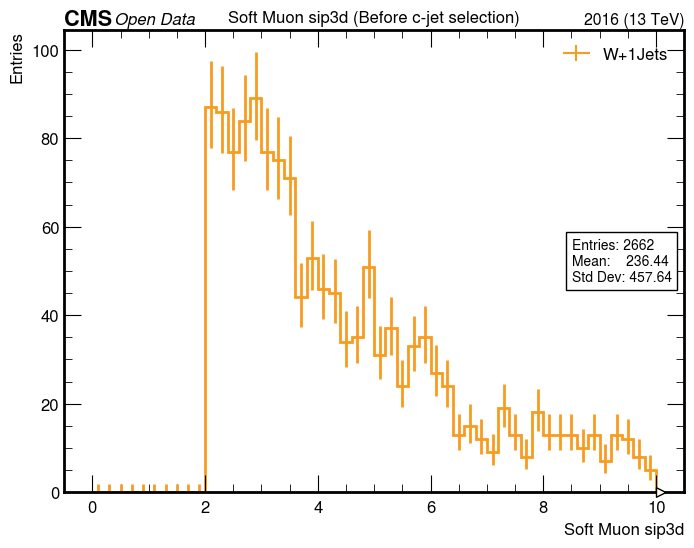

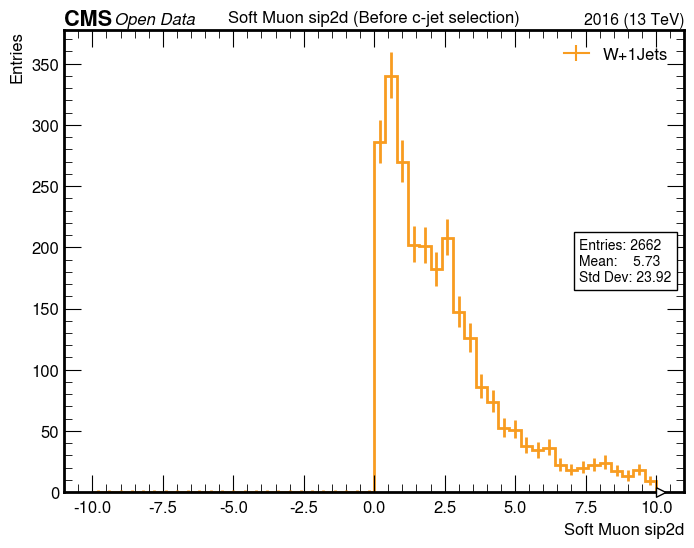

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Soft Muon sip2d (Before c-jet selection)'}, xlabel='Soft Muon sip2d', ylabel='Entries'>)

In [17]:
print("Generating histograms...")

# Number of RecoMuons histogram:
nRecoMuons = dak.num(Muon, axis=1)
make_hist(
    data=nRecoMuons,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of RecoMuons",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of RecoMuons (Raw Events)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# RecoMuon pT histogram:
RecoMuon_pt = dak.flatten(Muon.pt)
make_hist(
    data=RecoMuon_pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="RecoMuon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="RecoMuon $p_{T}$ (Raw Events)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Transverse Mass histogram:
transverse_mass = dak.flatten(Mt)
make_hist(
    data=transverse_mass,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="Transverse Mass $M_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="Transverse Mass $M_{T}$ (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of W muons histogram:
nWMuons = dak.num(W_Muons, axis=1)
make_hist(
    data=nWMuons,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of W Muons",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of Muons (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# W muon pT histogram:
W_Muon_pt = dak.flatten(W_Muons.pt)
make_hist(
    data=W_Muon_pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="W Muon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="W Muon $p_{T}$ (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of Reco Jets histogram:
nRecoJets = dak.num(Jet, axis=1)
make_hist( 
    data=nRecoJets, 
    nBins=10,
    lo=0, 
    hi=10, 
    xlabel="Number of RecoJets", 
    ylabel="Entries", 
    label="W+1Jets",
    title="Number of RecoJets (Raw Events)", 
    fname=None, 
    logy=False, 
    ax=None, 
    show=True, 
    return_hist=False, 
    show_stats=True, 
    histtype="step"
)

# Jets pT histogram:
RecoJet_pT = dak.flatten(Jet.pt)
make_hist(
    data=RecoJet_pT,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="RecoJet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="RecoJet $p_{T}$ (Raw Events)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of c-Jets:
nCJets = dak.num(c_Jets, axis=1)
make_hist(
    data=nCJets,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of c-Jets",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of c-Jets (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# c-Jet pT histogram:
cJet_pT = dak.flatten(c_Jets.pt)
make_hist(
    data=cJet_pT,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="c-Jet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="c-Jet $p_{T}$ (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of soft muons histogram:
nSoftMuons = dak.num(soft_muon, axis=1)
make_hist(
    data=nSoftMuons,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of Soft Muons",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of Soft Muons (Before c-jet selection)",
    fname=None,
    logy=True,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon pT histogram:
softMuon_pT = dak.flatten(soft_muon.pt)
make_hist(
    data=softMuon_pT,
    nBins=50,
    lo=0,
    hi=50,
    xlabel="Soft Muon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon $p_{T}$ (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon dxy histogram:
softMuon_dxy = dak.flatten(soft_muon.dxy)
make_hist(
    data=softMuon_dxy,
    nBins=50,
    lo=-0.5,
    hi=0.5,
    xlabel="Soft Muon dxy [cm]",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon dxy (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon sip3d histogram:
soft_muon_sip3d = dak.flatten(soft_muon.sip3d)
make_hist(
    data=soft_muon_sip3d,
    nBins=50,
    lo=0,
    hi=10,
    xlabel="Soft Muon sip3d",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon sip3d (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon sip2d histogram:
soft_muon_sip2d = dak.flatten(abs((soft_muon.dxy)/ soft_muon.dxyErr))
make_hist(
    data=soft_muon_sip2d,
    nBins=50,
    lo=-10,
    hi=10,
    xlabel="Soft Muon sip2d",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon sip2d (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

## 10. OS - SS Subtraction:

We subtract the **Same-Sign(SS)** background from **Opposite-Sign(OS)** $W+c$ events. 

1. **Opposite Sign (OS):** The events containing muon associated with the W-Boson and the soft muon associated with the charm should have opposite charges ($Q_{\mu, W} \neq Q_{\mu, soft}$).
2. **Same Sign (SS):** The events containing muons having same charge are treated as background and need to be reduced.
3. **OS-SS Subtraction:** We statistically subtract SS distribution from OS distribution, cancelling out the background.

Plotting OS vs SS c-jet pT...


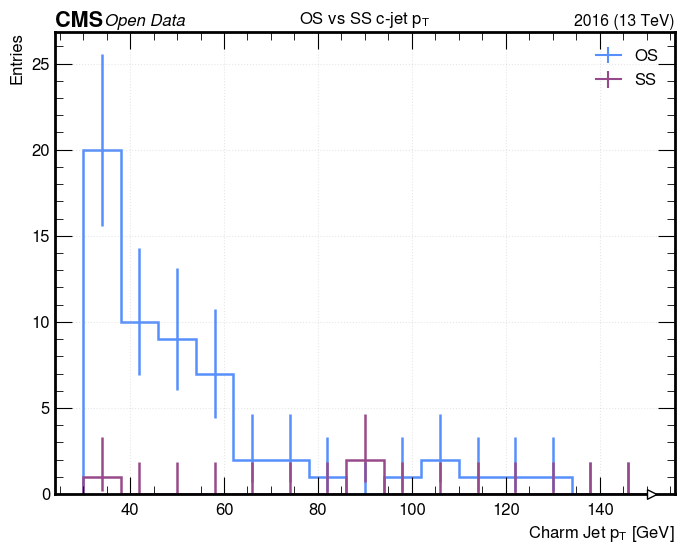

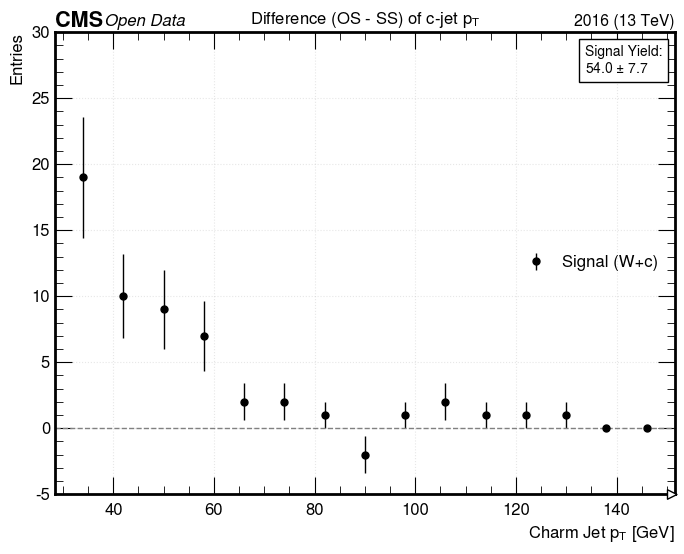

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Difference (OS - SS) of c-jet $p_T$'}, xlabel='Charm Jet $p_T$ [GeV]', ylabel='Entries'>,
 Hist(Regular(15, 30, 150, name='pt', label='Charm Jet $p_T$ [GeV]'), storage=Double()) # Sum: 54.0 (55.0 with flow),
 array([4.58257569, 3.16227766, 3.        , 2.64575131, 1.41421356,
        1.41421356, 1.        , 1.41421356, 1.        , 1.41421356,
        1.        , 1.        , 1.        , 0.        , 0.        ]))

In [18]:
print("Plotting OS vs SS c-jet pT...")

# Making an overlay histogram of OS and SS c-jet pT:
make_overlay_hist(
    cjet_pt_OS,
    cjet_pt_SS,
    bins=15,
    x_range=(30, 150),
    name="pt",
    xlabel=r"Charm Jet $p_T$ [GeV]",
    ylabel="Entries",
    title="OS vs SS c-jet $p_T$",
    labels=("OS", "SS"),
    colors=("C0", "C3"),
    normalize=False,
    flatten=False,
    histtype="step",
    show=True,
    grid=True,
    fname=None,
    yerr=True,
    linewidth=1.8,
 )

# Making a difference histogram (OS - SS) of c-jet pT:
make_diff_hist(
    cjet_pt_OS,
    cjet_pt_SS,
    bins=15,
    lo=30,
    ylo=-5,
    hi=150,
    yhi=30,
    name="pt",
    xlabel=r"Charm Jet $p_T$ [GeV]",
    ylabel="Entries",
    title="Difference (OS - SS) of c-jet $p_T$",
    diff_label="Signal (W+c)",
    color="k",
    normalize=False,
    flatten=False,
    histtype="errorbar",
    show=True,
    grid=True,
    fname=None,
    yerr=True,
    show_yield=True,
    label_loc="center right",
    yield_loc="upper right",
    return_errors=True,
 )

## 11. Yields and Event Selection Efficiency:

Here we see how many events actually make it past the passCuts:

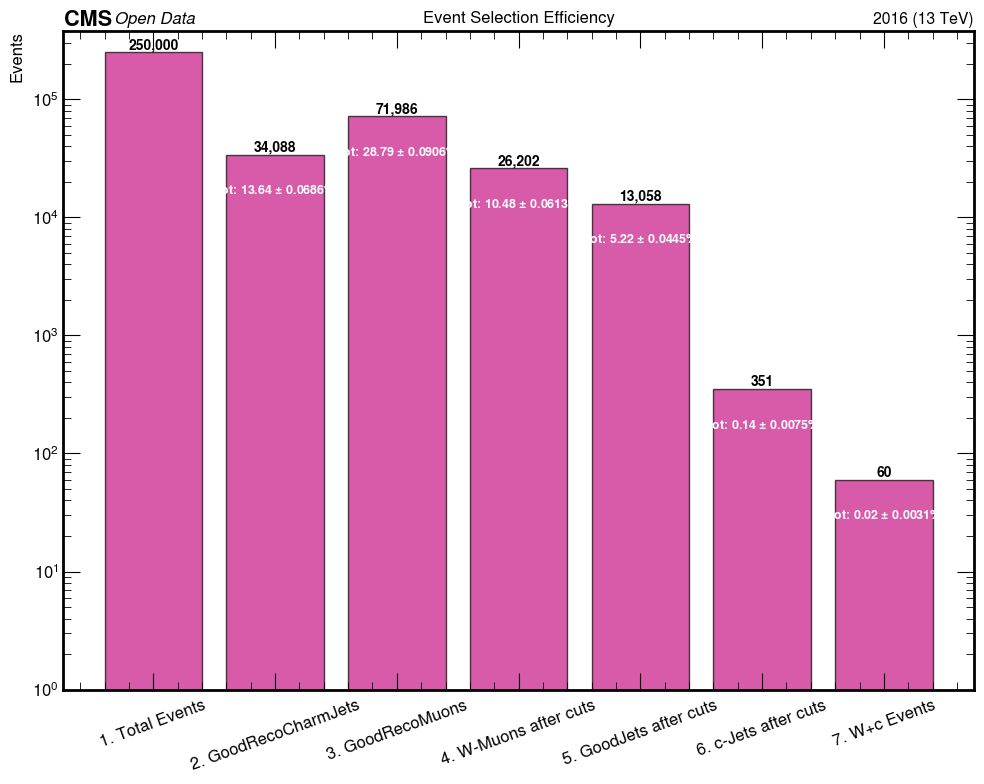


=== CUTFLOW SUMMARY ===
1. Total Events          : 250,000
2. GoodRecoCharmJets     : 34,088
3. GoodRecoMuons         : 71,986
4. W-Muons after cuts    : 26,202
5. GoodJets after cuts   : 13,058
6. c-Jets after cuts     : 351
7. W+c Events            : 60


In [25]:
import matplotlib.pyplot as plt
import mplhep as mh
def plot_cutflow(counts_dict):
    fig, ax = plt.subplots(figsize=(10, 8))
    labels = list(counts_dict.keys())

    values = []
    for value in counts_dict.values():
        try:
            values.append(float(value.compute()))
        except Exception:
            values.append(float(value))

    bars = ax.bar(labels, values, color="mediumvioletred", alpha=0.7, edgecolor="black")
    initial = values[0] if len(values) > 0 else 0.0

    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{int(val):,}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )

        if i > 0 and initial > 0:
            eff = val / initial
            eff_err = np.sqrt(eff * (1 - eff) / initial) if 0 <= eff <= 1 else 0.0

            eff_pct = eff * 100
            err_pct = eff_err * 100
            text_y = val / 2 if val > 0 else 0
            label = f"Tot: {eff_pct:.2f} $\\pm$ {err_pct:.4f}%"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                text_y,
                label,
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
                fontsize=9,
            )

    ax.set_yscale("log")
    ax.set_ylim(bottom=1)
    ax.set_ylabel("Events")
    ax.set_title("Event Selection Efficiency")
    ax.tick_params(axis="x", rotation=20)
    mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
    plt.tight_layout()
    plt.savefig("Plots/Analysis_Cutflow.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n=== CUTFLOW SUMMARY ===")
    for key, value in zip(labels, values):
        print(f"{key:25s}: {int(value):,}")

plot_cutflow(cutflow)

## 12. Background Selection:

We now select backgrounds like **W+cc, W+b, W+udsg** - (easiest to choose from W+Jets) (ttjets and others are in progress)

In [20]:
print("Categorizing background events...")

# Get all jets in W+c events
jets_Wc = Jet[Wc_evt_mask]

# Apply basic jet kinematic cuts
jet_passMask = (
    (jets_Wc.pt > 30) &
    (abs(jets_Wc.eta) < 2.4)
)
jets_Wc = jets_Wc[jet_passMask]

# Number of Hadron Flavor counts per events:
nC_hadron = dak.sum(jets_Wc.hadronFlavour == 4, axis=1)
nB_hadron = dak.sum(jets_Wc.hadronFlavour == 5, axis=1)

# W+cc, W+b, W+udsg event selections:
evt_Wcc = (nC_hadron >= 2) & (nB_hadron == 0)
evt_Wb = (nB_hadron >= 1)
evt_Wudsg = (nC_hadron == 0) & (nB_hadron == 0)

# Count events in each category
nWcc = int(dak.sum(evt_Wcc).compute())
nWb = int(dak.sum(evt_Wb).compute())
nWudsg = int(dak.sum(evt_Wudsg).compute())

print(f"W+cc events: {nWcc}")
print(f"W+b events: {nWb}")
print(f"W+udsg events: {nWudsg}")

Categorizing background events...
W+cc events: 0
W+b events: 0
W+udsg events: 0


Creating OS-SS overlay plots for backgrounds...


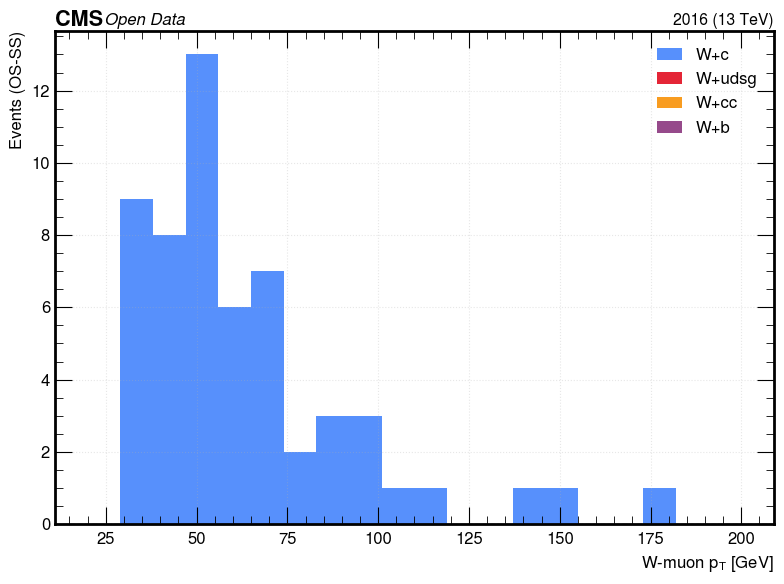

In [21]:
print("Creating OS-SS overlay plots for backgrounds...")

# Event-level OS/SS masks
evt_OS = dak.any(is_OS, axis=1)
evt_SS = dak.any(is_SS, axis=1)

# W-muon pt (scalar per event)
wmu_pt = Final_W.pt[:, 0]

# Extract W-muon pt for each category and OS/SS
wmu_pt_OS_Wc    = wmu_pt[evt_OS]
wmu_pt_SS_Wc    = wmu_pt[evt_SS]
wmu_pt_OS_Wcc   = wmu_pt[evt_OS & evt_Wcc]
wmu_pt_SS_Wcc   = wmu_pt[evt_SS & evt_Wcc]
wmu_pt_OS_Wb    = wmu_pt[evt_OS & evt_Wb]
wmu_pt_SS_Wb    = wmu_pt[evt_SS & evt_Wb]
wmu_pt_OS_Wudsg = wmu_pt[evt_OS & evt_Wudsg]
wmu_pt_SS_Wudsg = wmu_pt[evt_SS & evt_Wudsg]

# Create OS-SS histograms for each category
h_Wc_wmu    = os_ss_hist(wmu_pt_OS_Wc,    wmu_pt_SS_Wc,    bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")
h_Wcc_wmu   = os_ss_hist(wmu_pt_OS_Wcc,   wmu_pt_SS_Wcc,   bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")
h_Wb_wmu    = os_ss_hist(wmu_pt_OS_Wb,    wmu_pt_SS_Wb,    bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")
h_Wudsg_wmu = os_ss_hist(wmu_pt_OS_Wudsg, wmu_pt_SS_Wudsg, bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")

# Create overlay plot
fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_Wc_wmu,    ax=ax, label="W+c",    histtype="fill", lw=1.8, color="C0")
mh.histplot(h_Wudsg_wmu, ax=ax, label="W+udsg", histtype="fill", lw=1.8, color="C2")
mh.histplot(h_Wcc_wmu,   ax=ax, label="W+cc",   histtype="fill", lw=1.8, color="C1")
mh.histplot(h_Wb_wmu,    ax=ax, label="W+b",    histtype="fill", lw=1.8, color="C3")

mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
ax.set_xlabel(r"W-muon $p_T$ [GeV]")
ax.set_ylabel("Events (OS-SS)")
ax.axhline(0.0, color="0.5", lw=1, ls="--")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("Plots/Wmu_pt_OSSS_overlay_backgrounds.png", dpi=150, bbox_inches="tight")
plt.show()